# Data Visualization
This notebook visualizes the prepared YOLO-OBB dataset by showing the raw images alongside the annotated images with Oriented Bounding Boxes.

In [21]:
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up paths
data_dir = Path("data")
yaml_path = data_dir / "data.yaml"
train_images_dir = data_dir / "train" / "images"
train_labels_dir = data_dir / "train" / "labels"

In [22]:
# Load classes from data.yaml
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
    
classes = data_config['names']
print("Loaded classes:", classes)

# Get list of all images
all_images = list(train_images_dir.glob("*.jpg"))
print(f"Found {len(all_images)} training images.")

Loaded classes: {0: 'A1', 1: 'A2', 2: 'A3', 3: 'A4', 4: 'A5', 5: 'A6', 6: 'A7', 7: 'A8', 8: 'A9', 9: 'A10', 10: 'A11', 11: 'A12', 12: 'A13', 13: 'A14', 14: 'A15', 15: 'A16', 16: 'A17', 17: 'A18', 18: 'A19', 19: 'A20'}
Found 3073 training images.


In [23]:
def visualize_random_image():
    if not all_images:
        print("No images found! Make sure you've run the data_preparation notebook first.")
        return
        
    img_path = random.choice(all_images)
    label_path = train_labels_dir / f"{img_path.stem}.txt"
    
    # Read image
    # Convert BGR to RGB for matplotlib
    raw_img = cv2.imread(str(img_path))
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    
    annotated_img = raw_img.copy()
    h, w, _ = annotated_img.shape
    
    # Read labels
    if label_path.exists():
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 9:
                continue
                
            class_idx = int(parts[0])
            class_name = classes.get(class_idx, str(class_idx))
            
            # YOLO OBB format: class_idx x1 y1 x2 y2 x3 y3 x4 y4 (normalized)
            # Convert normalized coordinates to pixel coordinates
            pts = []
            for i in range(1, 9, 2):
                x = int(float(parts[i]) * w)
                y = int(float(parts[i+1]) * h)
                pts.append([x, y])
            
            pts = np.array(pts, np.int32)
            pts = pts.reshape((-1, 1, 2))
            
            # Draw polygon (Oriented Bounding Box)
            cv2.polylines(annotated_img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)
            
            # Put class text near the first point
            text_x, text_y = pts[0][0]
            cv2.putText(annotated_img, class_name, (text_x, max(text_y - 10, 10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    else:
        print(f"No label found for {img_path.name}")

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(raw_img)
    axes[0].set_title(f"Raw Image: {img_path.name}")
    axes[0].axis('off')
    
    axes[1].imshow(annotated_img)
    axes[1].set_title("Annotated Image (OBB)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

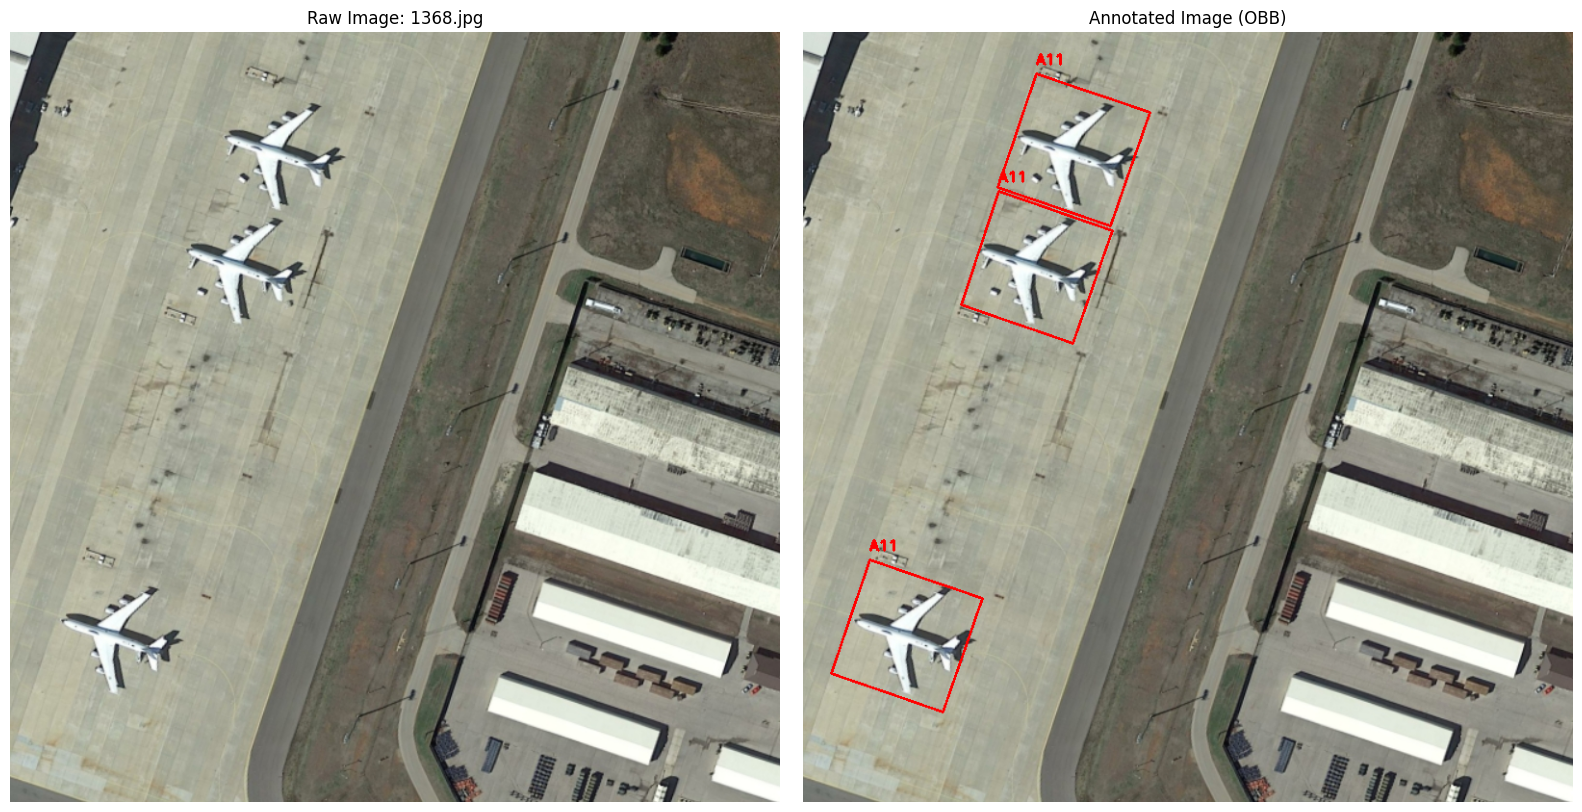

In [25]:
# Run the visualization
visualize_random_image()